In [33]:
# earnings acceleration and stock returns
# "earnings growth 의 변화속도가 미래 수익률을 예측한다."

In [34]:
import pandas as pd
import numpy as np

In [35]:
eps_df   = pd.read_csv("eps.csv", index_col ='Date', parse_dates = True)
adj_close_df = pd.read_csv("수정주가.csv", index_col = 'Date', parse_dates = True)

adj_close_df = adj_close_df.apply(pd.to_numeric, errors = "coerce")
eps_df = eps_df.apply(pd.to_numeric, errors = "coerce")

In [36]:
ret_m = adj_close_df.resample('ME').last().pct_change(fill_method=None)
eps_q = eps_df.resample("QE").last()

In [52]:
# 3) 백테스트 기간을 설정하여 3월 말 날짜 리스트 생성
from pandas.tseries.offsets import YearEnd

start_date = '2006-12-31'
end_date   = '2025-12-31'
year_ends = pd.date_range(start=start_date, end=end_date, freq=YearEnd(month=3)).tolist()

# 4) 포트폴리오 수익률을 저장할 Series 객체 생성
portfolio_returns = pd.Series(index=year_ends, dtype=float)
portfolio_returns

2007-03-31   NaN
2008-03-31   NaN
2009-03-31   NaN
2010-03-31   NaN
2011-03-31   NaN
2012-03-31   NaN
2013-03-31   NaN
2014-03-31   NaN
2015-03-31   NaN
2016-03-31   NaN
2017-03-31   NaN
2018-03-31   NaN
2019-03-31   NaN
2020-03-31   NaN
2021-03-31   NaN
2022-03-31   NaN
2023-03-31   NaN
2024-03-31   NaN
2025-03-31   NaN
dtype: float64

In [53]:
eps_q_shifted = eps_q.shift(4)

In [56]:
# earnings growth
earnings_growth = (eps_q_shifted - eps_q_shifted.shift(4)) / eps_q_shifted.shift(4).abs()

# earnings acceleration 계산
earnings_accel = earnings_growth - earnings_growth.shift(1)

# 이상치 제거
earnings_accel = earnings_accel.replace([np.inf, -np.inf], np.nan)

# earnings_accel

In [57]:
for i in range(0, len(year_ends) - 1):
    start_date = year_ends[i]
    end_date = year_ends[i + 1]

    signal = earnings_accel.loc[start_date].dropna()

    if len(signal) == 0:
        continue

    long = signal.nlargest(int(len(signal) * 0.2)).index
    
    if len(long) == 0:
        continue
    
    # 다음 달 수익률로 동일가중 수익률 계산
    period_ret = ret_m.loc[end_date, ret_m.columns.intersection(long)].dropna()
    if period_ret.empty:
        continue
    
    portfolio_returns.loc[end_date] = period_ret.mean()

In [58]:
portfolio_returns

2007-03-31         NaN
2008-03-31   -0.044534
2009-03-31    0.102453
2010-03-31    0.029066
2011-03-31    0.058497
2012-03-31   -0.043086
2013-03-31    0.047517
2014-03-31    0.024262
2015-03-31    0.073519
2016-03-31    0.058800
2017-03-31    0.023486
2018-03-31    0.034567
2019-03-31   -0.001457
2020-03-31   -0.123599
2021-03-31    0.085386
2022-03-31    0.072564
2023-03-31    0.012480
2024-03-31    0.022071
2025-03-31   -0.065122
dtype: float64

In [67]:
nav = (1 + portfolio_returns.fillna(0)).cumprod()
nav

2007-03-31    1.000000
2008-03-31    0.955466
2009-03-31    1.053356
2010-03-31    1.083972
2011-03-31    1.147381
2012-03-31    1.097946
2013-03-31    1.150116
2014-03-31    1.178020
2015-03-31    1.264628
2016-03-31    1.338988
2017-03-31    1.370436
2018-03-31    1.417808
2019-03-31    1.415742
2020-03-31    1.240758
2021-03-31    1.346701
2022-03-31    1.444422
2023-03-31    1.462448
2024-03-31    1.494727
2025-03-31    1.397387
dtype: float64

<Axes: >

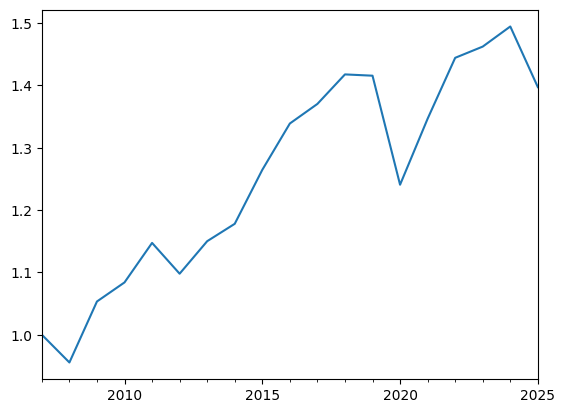

In [69]:
nav.plot()

In [70]:
# 무위험 수익률 (연 2%)
rf_annual = 0.02
# 수익률 시리즈 (월별, NaN 제외)
returns = portfolio_returns.dropna()

# 1) CAGR
start_val = 1.0
end_val = nav.iloc[-1] / nav.iloc[0]   # 이미 초기값 1이면 nav.iloc[-1]만 써도 됨
years = (nav.index[-1] - nav.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0

# 2) 연 변동성
volatility = returns.std()

# 3) Sharpe Ratio (연환산 기준, 무위험 2%)
excess_return = returns.mean() - rf_annual
sharpe_ratio = (excess_return / volatility) if volatility > 0 else np.nan

# CAGR 계산
print(f"CAGR: {cagr:.2%}")
# 연 환산 변동성 계산
print(f"Annualized Volatility: {volatility:.2%}")
# Sharpe Ratio 계산
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

CAGR: 1.88%
Annualized Volatility: 5.81%
Sharpe Ratio: 0.01
